# Setup ML + Data Verification

Pada tahap ini dilakukan **persiapan environment Machine Learning** dan **verifikasi data** yang akan digunakan untuk proses regresi.

Tahap ini **belum melakukan training model**. Fokusnya adalah memastikan seluruh kebutuhan ML1 sudah siap dan data dari Data Engineer dapat digunakan dengan benar.


## 2. Pekerjaan yang Dilakukan

### 1 Menyiapkan Environment Machine Learning
### 2.2 Memastikan Branch dan Project Sudah Ter-update

- Bekerja pada branch `feature/ml1-mack`
- Mengambil update terbaru dari branch `dev`
- Memastikan file hasil pekerjaan Data Engineer sudah tersedia
### 2.3 Memverifikasi Dataset
Dataset yang digunakan berasal dari hasil preprocessing Data Engineer:

- `data/processed/CCPP_train.csv`
- `data/processed/CCPP_test.csv`
### 2.4 Menentukan Feature dan Target

**Features:**
- `AT` — Ambient Temperature
- `V` — Exhaust Vacuum
- `AP` — Ambient Pressure
- `RH` — Relative Humidity

**Target:**

- `PE` — Electrical Power Output

> `PE` tidak digunakan sebagai feature input karena merupakan nilai yang akan diprediksi.

### 2.5 Memuat Regression Scaler

Scaler hasil preprocessing Data Engineer akan digunakan kembali:

`models/regression_scaler.pkl`

Scaler **tidak dibuat ulang** pada tahap ini.

Scaler yang sudah di-fit pada data training digunakan untuk:

- melakukan transform pada `X_train`
- melakukan transform pada `X_test`

Tidak dilakukan `fit` ulang menggunakan data test.

### 2.6 Memverifikasi Hasil Scaling

## 3. Output yang Pekerjaan
- Environment ML yang siap digunakan
- Dataset training dan testing berhasil dibaca
- Feature dan target sudah ditentukan
- Regression scaler berhasil digunakan
- `X_train_scaled` berhasil dibuat
- `X_test_scaled` berhasil dibuat
- Dataset siap digunakan untuk training model regresi

Setup ML + Data Verification
Tujuan

Pada tahap ini dilakukan persiapan environment Machine Learning dan verifikasi data yang akan digunakan untuk proses regresi.

Tahap ini belum melakukan training model. Fokusnya adalah memastikan seluruh kebutuhan ML1 sudah siap dan data dari Data Engineer dapat digunakan dengan benar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
train_df = pd.read_csv(
    "../data/processed/CCPP_train.csv"
)

test_df = pd.read_csv(
    "../data/processed/CCPP_test.csv"
)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (7621, 5)
Test : (1906, 5)


In [3]:
features = ["AT", "V", "AP", "RH"]
target = "PE"

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [4]:
regression_scaler = joblib.load(
    "../models/regression_scaler.pkl"
)

X_train_scaled = regression_scaler.transform(X_train)
X_test_scaled = regression_scaler.transform(X_test)

In [5]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

y_pred_linear = linear_model.predict(
    X_test_scaled
)

In [6]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
MAE : 3.6214672910209487
RMSE: 4.587499007655297
R²  : 0.9283920303369918


#Linear Regression Baseline Experiment

## 1. Tujuan

Tahap ini bertujuan membangun model **Linear Regression** sebagai
baseline untuk memprediksi Electrical Power Output (`PE`) pada dataset
Combined Cycle Power Plant.

Linear Regression digunakan sebagai model pembanding awal, bukan sebagai
kesimpulan bahwa model tersebut merupakan model final.

## 2. Input dan Target

### Features

- `AT` — Ambient Temperature
- `V` — Exhaust Vacuum
- `AP` — Ambient Pressure
- `RH` — Relative Humidity

### Target

- `PE` — Electrical Power Output

## 3. Data yang Digunakan

Data berasal dari hasil Data Engineering:

- `data/processed/CCPP_train.csv`
- `data/processed/CCPP_test.csv`

Pembagian data:

- Training: 80%
- Testing: 20%

## 4. Preprocessing

Regression scaler yang telah disiapkan oleh Data Engineer digunakan
kembali untuk melakukan transformasi fitur.

Scaler tidak di-fit ulang pada data testing.

## 5. Pembangunan Model

Model yang digunakan pada tahap ini:

**Linear Regression**

Tahapan:

1. Load data training dan testing.
2. Memisahkan feature dan target.
3. Menggunakan regression scaler.
4. Melatih Linear Regression pada training data.
5. Melakukan prediksi pada testing data.

## 6. Evaluasi Model

Model dievaluasi menggunakan:

- **MAE (Mean Absolute Error)**
- **RMSE (Root Mean Squared Error)**
- **R² (R-squared)**

Selain metrik numerik, dilakukan visualisasi:

- Actual vs Predicted
- Residual Plot

## 7. Output

Tahap ini menghasilkan:

- Model Linear Regression baseline
- Nilai MAE
- Nilai RMSE
- Nilai R²
- Grafik Actual vs Predicted
- Grafik Residual

Hasil baseline akan digunakan sebagai pembanding pada tahap
perbandingan model berikutnya.


In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
linear_model = LinearRegression()

print(linear_model)

LinearRegression()


In [9]:
linear_model.fit(
    X_train_scaled,
    y_train
)

print("Linear Regression training selesai.")

Linear Regression training selesai.


In [10]:
y_pred_linear = linear_model.predict(
    X_test_scaled
)

print("Jumlah prediction:", len(y_pred_linear))

Jumlah prediction: 1906


In [11]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

print("MAE:", mae_linear)

MAE: 3.6214672910209487


In [12]:
rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

print("RMSE:", rmse_linear)

RMSE: 4.587499007655297


In [13]:
r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("R²:", r2_linear)

R²: 0.9283920303369918


In [14]:
linear_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae_linear],
    "RMSE": [rmse_linear],
    "R2": [r2_linear]
})

linear_results

,Model,MAE,RMSE,R2
0,Linear Regression,3.621467,4.587499,0.928392


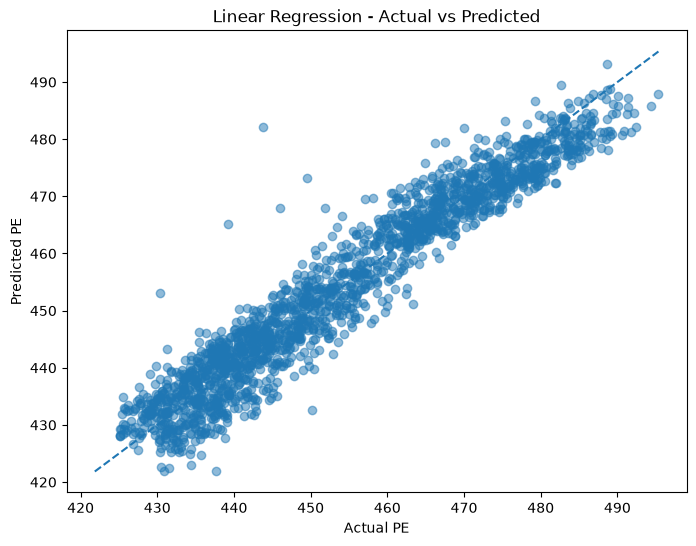

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    y_pred_linear.min()
)

max_value = max(
    y_test.max(),
    y_pred_linear.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual PE")
plt.ylabel("Predicted PE")
plt.title("Linear Regression - Actual vs Predicted")

plt.show()

In [16]:
residuals_linear = y_test - y_pred_linear

print(residuals_linear.describe())

count    1906.000000
mean        0.014937
std         4.588679
min       -38.357920
25%        -3.082038
50%        -0.083998
75%         3.226198
max        17.475101
Name: PE, dtype: float64


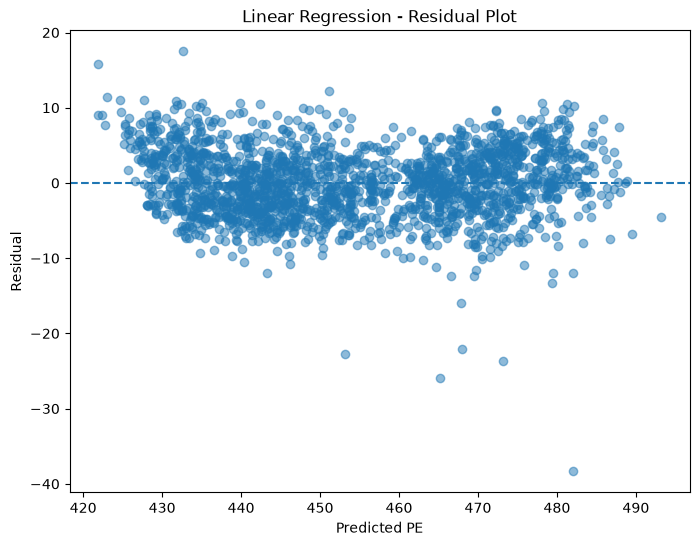

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_linear,
    residuals_linear,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted PE")
plt.ylabel("Residual")
plt.title("Linear Regression - Residual Plot")

plt.show()

In [18]:
coefficient_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
})

coefficient_df

,Feature,Coefficient
0,AT,-14.669542
1,V,-2.979750
2,AP,0.373747
3,RH,-2.297659


In [19]:
print("Intercept:", linear_model.intercept_)

Intercept: 454.33761317412416


In [20]:
linear_results.to_csv(
    "../models/ml1_baseline_results.csv",
    index=False
)

## Interpretasi Linear Regression Baseline

Model Linear Regression berhasil dilatih menggunakan empat variabel
input, yaitu AT, V, AP, dan RH.

Evaluasi dilakukan pada data testing menggunakan MAE, RMSE, dan R².

Hasil evaluasi digunakan sebagai baseline untuk membandingkan model
regression lain pada tahap berikutnya.

Scatter plot Actual vs Predicted digunakan untuk melihat kedekatan
prediksi terhadap nilai aktual, sedangkan residual plot digunakan untuk
melihat pola kesalahan prediksi.

Koefisien model juga diperiksa sebagai informasi tambahan mengenai arah
dan besarnya hubungan setiap feature terhadap prediksi setelah proses
standardisasi.

Hasil Linear Regression pada tahap ini belum digunakan sebagai model
final. Model berikutnya akan dibandingkan menggunakan dataset dan
metrik evaluasi yang sama.

# Regression Model Comparison

## 1. Tujuan

Tahap ini bertujuan membandingkan beberapa algoritma regression untuk
memprediksi Electrical Power Output (`PE`) pada dataset Combined Cycle
Power Plant.

Model yang dibandingkan:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

Linear Regression digunakan sebagai baseline dari tahap sebelumnya,
sedangkan Random Forest dan Gradient Boosting digunakan untuk menguji
model berbasis tree yang mampu mempelajari hubungan non-linear.

## 2. Data dan Features

Features:

- `AT` — Ambient Temperature
- `V` — Exhaust Vacuum
- `AP` — Ambient Pressure
- `RH` — Relative Humidity

Target:

- `PE` — Electrical Power Output

Semua model menggunakan training set dan testing set yang sama agar
perbandingan dilakukan secara konsisten.

## 3. Preprocessing

Linear Regression menggunakan fitur yang telah ditransformasi dengan
regression scaler.

Random Forest Regressor dan Gradient Boosting Regressor menggunakan fitur
asli karena model berbasis decision tree tidak memerlukan standardisasi
fitur untuk proses pemisahan node.

## 4. Model

Model yang digunakan:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Pada tahap ini belum dilakukan hyperparameter tuning.

## 5. Evaluation Metrics

Setiap model dievaluasi menggunakan:

- MAE
- RMSE
- R²

Hasil evaluasi disimpan dalam satu tabel untuk memudahkan perbandingan.

## 6. Additional Analysis

Random Forest dianalisis menggunakan feature importance untuk melihat
kontribusi relatif masing-masing feature terhadap model.

Feature importance digunakan sebagai informasi interpretasi model dan
bukan sebagai bukti hubungan sebab-akibat.

## 7. Output

Tahap ini menghasilkan:

- hasil evaluasi tiga model
- tabel perbandingan MAE, RMSE, dan R²
- feature importance Random Forest
- visualisasi feature importance
- file hasil perbandingan model

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

### Buat Random Forest

In [22]:
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

y_pred_rf = random_forest_model.predict(
    X_test
)

### Evaluasi Random Forest

In [23]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [mae_rf],
    "RMSE": [rmse_rf],
    "R2": [r2_rf]
})

rf_results

,Model,MAE,RMSE,R2
0,Random Forest,2.412938,3.44222,0.959683


### Gradient Boosting

In [24]:
gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

gradient_boosting_model.fit(
    X_train,
    y_train
)

y_pred_gb = gradient_boosting_model.predict(
    X_test
)

### Evaluasi Gradient Boosting

In [25]:
mae_gb = mean_absolute_error(
    y_test,
    y_pred_gb
)

rmse_gb = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_gb
    )
)

r2_gb = r2_score(
    y_test,
    y_pred_gb
)

gb_results = pd.DataFrame({
    "Model": ["Gradient Boosting"],
    "MAE": [mae_gb],
    "RMSE": [rmse_gb],
    "R2": [r2_gb]
})

gb_results

,Model,MAE,RMSE,R2
0,Gradient Boosting,3.006688,3.983519,0.946006


#### fungsi evaluasi

In [28]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "R2": r2_score(y_true, y_pred)
    }

In [29]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        y_pred_linear
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        y_pred_gb
    )
)

results_df = pd.DataFrame(results)

results_df.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,R2
1,Random Forest,2.412938,3.442220,0.959683
2,Gradient Boosting,3.006688,3.983519,0.946006
0,Linear Regression,3.621467,4.587499,0.928392


## Analisis Hasil Model Comparison

Berdasarkan hasil pengujian pada data testing, diperoleh performa sebagai
berikut:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Random Forest | 2.412938 | 3.442220 | 0.959683 |
| Gradient Boosting | 3.006688 | 3.983519 | 0.946006 |
| Linear Regression | 3.621467 | 4.587499 | 0.928392 |

MAE dan RMSE digunakan untuk mengukur besarnya error prediksi, sehingga
nilai yang lebih kecil menunjukkan error yang lebih rendah. R² digunakan
untuk mengukur proporsi variasi target yang dapat dijelaskan oleh model,
sehingga nilai yang lebih tinggi menunjukkan kemampuan penjelasan yang
lebih besar.

Pada hasil pengujian ini, Random Forest menghasilkan nilai MAE dan RMSE
terendah serta R² tertinggi dibandingkan Linear Regression dan Gradient
Boosting.

Hasil ini menunjukkan bahwa Random Forest mampu menangkap pola hubungan
antara variabel AT, V, AP, dan RH dengan PE secara lebih baik pada data
testing yang digunakan dalam eksperimen ini.

Namun, Random Forest belum ditetapkan sebagai model final karena masih
perlu dilakukan pengujian menggunakan fitur hasil feature engineering
serta validasi tambahan pada tahap berikutnya.

# Feature Engineering + Validation

## Tujuan

Tahap ini bertujuan untuk **mengevaluasi apakah penambahan fitur hasil feature engineering dapat meningkatkan performa model supervised learning regression** dalam memprediksi `Electrical Power Output (PE)` pada dataset Combined Cycle Power Plant (CCPP).

Proses dilakukan dengan membandingkan dua jenis feature set:

### Baseline Features
- `AT` — Ambient Temperature
- `V` — Exhaust Vacuum
- `AP` — Ambient Pressure
- `RH` — Relative Humidity

### Engineered Features
- `AT`
- `V`
- `AP`
- `RH`
- `AT_squared`
- `AT_V_interaction`
- `AP_RH_ratio`

Selain perbandingan pada data testing, dilakukan **5-Fold Cross-Validation** pada data training untuk melihat konsistensi performa model.

## Sasaran

Proses ini dilakukan untuk:

1. Mengetahui apakah fitur tambahan memberikan peningkatan performa model.
2. Membandingkan performa baseline features dengan engineered features.
3. Mengevaluasi model menggunakan metrik:
   - **MAE (Mean Absolute Error)**
   - **RMSE (Root Mean Squared Error)**
   - **R² (R-Squared)**
4. Mengurangi kemungkinan kesimpulan yang hanya bergantung pada satu pembagian data melalui 5-Fold Cross-Validation.
5. Menentukan feature set yang akan dipertimbangkan untuk tahap pembangunan model final.

## Catatan

Feature engineering tidak dianggap berhasil hanya berdasarkan korelasi fitur terhadap target. Keputusan penggunaan fitur tambahan akan didasarkan pada hasil evaluasi performa model dan validasi silang.

Pada tahap ini, `PE` tetap menjadi **target prediction** dan tidak digunakan sebagai fitur input.

###  Load Data

Menggunakan data training dan testing hasil preprocessing Data Engineering.

- `CCPP_train.csv` digunakan untuk training dan cross-validation.
- `CCPP_test.csv` digunakan untuk evaluasi akhir pada test set.
- Target yang diprediksi adalah `PE`.

In [31]:
train_df = pd.read_csv("../data/processed/CCPP_train.csv")
test_df = pd.read_csv("../data/processed/CCPP_test.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

display(train_df.head())

Train shape: (7621, 5)
Test shape : (1906, 5)


,AT,V,AP,RH,PE
0,10.51,37.50,1010.70,96.29,474.24
1,23.02,63.47,1012.21,80.61,443.66
2,14.40,42.18,1015.47,77.70,464.81
3,23.35,59.92,1009.86,88.60,439.82
4,23.71,50.23,1017.55,73.24,458.59


### Feature Engineering

Pada tahap ini, ML1 menggunakan fitur hasil **feature engineering yang telah disiapkan pada tahap Data Engineering**.

Dataset CCPP pada awalnya memiliki empat fitur input utama:

- `AT` — Ambient Temperature
- `V` — Exhaust Vacuum
- `AP` — Ambient Pressure
- `RH` — Relative Humidity

Berdasarkan tahap feature engineering sebelumnya, dibuat tiga fitur turunan:

- `AT_squared` = `AT²`
- `AT_V_interaction` = `AT × V`
- `AP_RH_ratio` = `AP / RH`

Fitur-fitur tersebut tidak berasal dari kolom baru pada dataset asli, tetapi merupakan hasil transformasi dan kombinasi dari fitur yang sudah tersedia.

ketiga fitur tersebut diperlakukan sebagai **candidate engineered features** untuk diuji terhadap feature set baseline.

### Baseline Features

```text
AT
V
AP
RH

In [42]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tambahkan root project ke Python path
sys.path.append("..")

from src.feature_engineering import create_features

print("Library berhasil di-import.")

Library berhasil di-import.


In [43]:

print(create_features)

<function create_features at 0x00000209B043C680>


In [36]:
train_fe = create_features(train_df.copy())
test_fe = create_features(test_df.copy())

print("Kolom train setelah feature engineering:")
print(train_fe.columns.tolist())

print("\nKolom test setelah feature engineering:")
print(test_fe.columns.tolist())

Kolom train setelah feature engineering:
['AT', 'V', 'AP', 'RH', 'AT_squared', 'AT_V_interaction', 'AP_RH_ratio']

Kolom test setelah feature engineering:
['AT', 'V', 'AP', 'RH', 'AT_squared', 'AT_V_interaction', 'AP_RH_ratio']


In [37]:
engineered_features = [
    "AT_squared",
    "AT_V_interaction",
    "AP_RH_ratio"
]

for feature in engineered_features:
    print(
        f"{feature}:",
        "OK" if feature in train_fe.columns else "TIDAK DITEMUKAN"
    )

AT_squared: OK
AT_V_interaction: OK
AP_RH_ratio: OK


In [38]:
display(
    train_fe[
        [
            "AT",
            "V",
            "AP",
            "RH",
            "AT_squared",
            "AT_V_interaction",
            "AP_RH_ratio"
        ]
    ].head()
)

,AT,V,AP,RH,AT_squared,AT_V_interaction,AP_RH_ratio
0,10.51,37.50,1010.70,96.29,110.4601,394.1250,10.496417
1,23.02,63.47,1012.21,80.61,529.9204,1461.0794,12.556879
2,14.40,42.18,1015.47,77.70,207.3600,607.3920,13.069112
3,23.35,59.92,1009.86,88.60,545.2225,1399.1320,11.397968
4,23.71,50.23,1017.55,73.24,562.1641,1190.9533,13.893364


In [39]:
print("Missing values:")
print(train_fe[engineered_features].isna().sum())

print("\nInfinite values:")
print(np.isinf(train_fe[engineered_features]).sum())

Missing values:
AT_squared          0
AT_V_interaction    0
AP_RH_ratio         0
dtype: int64

Infinite values:
AT_squared          0
AT_V_interaction    0
AP_RH_ratio         0
dtype: int64


In [45]:
baseline_features = [
    "AT",
    "V",
    "AP",
    "RH"
]

engineered_feature_set = [
    "AT",
    "V",
    "AP",
    "RH",
    "AT_squared",
    "AT_V_interaction",
    "AP_RH_ratio"
]

target = "PE"

# Fitur baseline
X_train_baseline = train_fe[baseline_features]
X_test_baseline = test_fe[baseline_features]

# Fitur hasil feature engineering
X_train_engineered = train_fe[engineered_feature_set]
X_test_engineered = test_fe[engineered_feature_set]

# Target tetap diambil dari dataset asli
y_train = train_df[target]
y_test = test_df[target]

print("X_train baseline   :", X_train_baseline.shape)
print("X_train engineered :", X_train_engineered.shape)
print("y_train            :", y_train.shape)
print("y_test             :", y_test.shape)

X_train baseline   : (7621, 4)
X_train engineered : (7621, 7)
y_train            : (7621,)
y_test             : (1906,)


### Random Forest — Baseline Features

Model baseline menggunakan empat fitur asli dari dataset CCPP, yaitu `AT`, `V`, `AP`, dan `RH`.

Model ini digunakan sebagai pembanding untuk mengetahui perubahan performa setelah penambahan fitur hasil feature engineering.

In [46]:
rf_baseline = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(
    X_train_baseline,
    y_train
)

y_pred_baseline = rf_baseline.predict(
    X_test_baseline
)

mae_baseline = mean_absolute_error(
    y_test,
    y_pred_baseline
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_baseline
    )
)

r2_baseline = r2_score(
    y_test,
    y_pred_baseline
)

print("Baseline Random Forest")
print(f"MAE  : {mae_baseline:.6f}")
print(f"RMSE : {rmse_baseline:.6f}")
print(f"R²   : {r2_baseline:.6f}")

Baseline Random Forest
MAE  : 2.405946
RMSE : 3.431440
R²   : 0.959935


### Random Forest — Engineered Features

Pada tahap ini, model Random Forest dilatih menggunakan fitur asli dari dataset (`AT`, `V`, `AP`, dan `RH`) ditambah tiga fitur hasil feature engineering, yaitu `AT_squared`, `AT_V_interaction`, dan `AP_RH_ratio`.

Konfigurasi Random Forest dibuat sama dengan model baseline agar perbedaan performa dapat diamati berdasarkan penggunaan feature set.

In [47]:
rf_engineered = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_engineered.fit(
    X_train_engineered,
    y_train
)

y_pred_engineered = rf_engineered.predict(
    X_test_engineered
)

mae_engineered = mean_absolute_error(
    y_test,
    y_pred_engineered
)

rmse_engineered = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_engineered
    )
)

r2_engineered = r2_score(
    y_test,
    y_pred_engineered
)

print("Engineered Random Forest")
print(f"MAE  : {mae_engineered:.6f}")
print(f"RMSE : {rmse_engineered:.6f}")
print(f"R²   : {r2_engineered:.6f}")

Engineered Random Forest
MAE  : 2.450048
RMSE : 3.477157
R²   : 0.958861


### 5-Fold Cross-Validation

Untuk mengevaluasi konsistensi performa model, dilakukan 5-Fold Cross-Validation pada data training.

Baseline features dan engineered features diuji menggunakan konfigurasi Random Forest yang sama.

Metrik yang digunakan adalah:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (R-Squared)

Nilai yang digunakan untuk perbandingan adalah rata-rata performa dari lima fold.

In [48]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

print("5-Fold Cross-Validation siap digunakan.")

5-Fold Cross-Validation siap digunakan.


### Cross-Validation — Baseline Features

Cross-Validation dilakukan menggunakan baseline features (`AT`, `V`, `AP`, dan `RH`) untuk memperoleh gambaran performa model pada lima pembagian data training.

Model yang digunakan tetap Random Forest dengan konfigurasi yang sama seperti pengujian baseline sebelumnya.

In [49]:
rf_cv_baseline = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

cv_baseline = cross_validate(
    rf_cv_baseline,
    X_train_baseline,
    y_train,
    cv=kf,
    scoring=cv_scoring,
    n_jobs=-1
)

cv_baseline_mae = -cv_baseline["test_MAE"].mean()
cv_baseline_rmse = -cv_baseline["test_RMSE"].mean()
cv_baseline_r2 = cv_baseline["test_R2"].mean()

print("Baseline Random Forest - 5 Fold Cross-Validation")
print(f"Mean MAE  : {cv_baseline_mae:.6f}")
print(f"Mean RMSE : {cv_baseline_rmse:.6f}")
print(f"Mean R²   : {cv_baseline_r2:.6f}")

Baseline Random Forest - 5 Fold Cross-Validation
Mean MAE  : 2.444547
Mean RMSE : 3.405214
Mean R²   : 0.959844


### Cross-Validation — Engineered Features

Cross-Validation selanjutnya dilakukan menggunakan engineered feature set yang terdiri dari fitur asli (`AT`, `V`, `AP`, `RH`) serta tiga fitur hasil feature engineering (`AT_squared`, `AT_V_interaction`, dan `AP_RH_ratio`).

Konfigurasi Random Forest dan skema 5-Fold Cross-Validation dibuat sama dengan baseline agar hasil dapat dibandingkan secara konsisten.

In [50]:
rf_cv_engineered = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

cv_engineered = cross_validate(
    rf_cv_engineered,
    X_train_engineered,
    y_train,
    cv=kf,
    scoring=cv_scoring,
    n_jobs=-1
)

cv_engineered_mae = -cv_engineered["test_MAE"].mean()
cv_engineered_rmse = -cv_engineered["test_RMSE"].mean()
cv_engineered_r2 = cv_engineered["test_R2"].mean()

print("Engineered Random Forest - 5 Fold Cross-Validation")
print(f"Mean MAE  : {cv_engineered_mae:.6f}")
print(f"Mean RMSE : {cv_engineered_rmse:.6f}")
print(f"Mean R²   : {cv_engineered_r2:.6f}")

Engineered Random Forest - 5 Fold Cross-Validation
Mean MAE  : 2.513219
Mean RMSE : 3.481429
Mean R²   : 0.958055


### Perbandingan 5-Fold Cross-Validation

Rata-rata hasil 5-Fold Cross-Validation pada data training adalah sebagai berikut:

| Feature Set | Mean MAE | Mean RMSE | Mean R² |
|---|---:|---:|---:|
| Baseline | 2.444547 | 3.405214 | 0.959844 |
| Engineered | 2.513219 | 3.481429 | 0.958055 |

Hasil Cross-Validation menunjukkan pola yang konsisten dengan evaluasi test set, yaitu engineered feature set belum memberikan peningkatan performa dibandingkan baseline feature set.

In [51]:
comparison = pd.DataFrame({
    "Feature Set": [
        "Baseline",
        "Engineered"
    ],
    "MAE": [
        mae_baseline,
        mae_engineered
    ],
    "RMSE": [
        rmse_baseline,
        rmse_engineered
    ],
    "R2": [
        r2_baseline,
        r2_engineered
    ]
})

comparison = comparison.round(6)

display(comparison)

,Feature Set,MAE,RMSE,R2
0,Baseline,2.405946,3.431440,0.959935
1,Engineered,2.450048,3.477157,0.958861


In [52]:
comparison.to_csv(
    "../models/ml1_feature_engineering_comparison.csv",
    index=False
)

print("Test set comparison berhasil disimpan.")

Test set comparison berhasil disimpan.


In [53]:
cv_comparison = pd.DataFrame({
    "Feature Set": [
        "Baseline",
        "Engineered"
    ],
    "CV MAE": [
        cv_baseline_mae,
        cv_engineered_mae
    ],
    "CV RMSE": [
        cv_baseline_rmse,
        cv_engineered_rmse
    ],
    "CV R2": [
        cv_baseline_r2,
        cv_engineered_r2
    ]
})

cv_comparison = cv_comparison.round(6)

display(cv_comparison)

,Feature Set,CV MAE,CV RMSE,CV R2
0,Baseline,2.444547,3.405214,0.959844
1,Engineered,2.513219,3.481429,0.958055


In [54]:
cv_comparison.to_csv(
    "../models/ml1_cross_validation_comparison.csv",
    index=False
)

print("Cross-validation comparison berhasil disimpan.")

Cross-validation comparison berhasil disimpan.


## 11. Feature Importance

Feature importance digunakan untuk melihat kontribusi relatif setiap fitur terhadap prediksi Random Forest pada engineered feature set.

Analisis ini membantu melihat apakah fitur hasil feature engineering seperti `AT_squared`, `AT_V_interaction`, dan `AP_RH_ratio` digunakan oleh model serta seberapa besar nilai importance masing-masing fitur.

Hasil feature importance digunakan sebagai analisis pendukung dan tidak menjadi satu-satunya dasar dalam menentukan feature set yang digunakan pada tahap model final.

In [55]:
feature_importance = pd.DataFrame({
    "Feature": engineered_feature_set,
    "Importance": rf_engineered.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
5,AT_V_interaction,0.872991
0,AT,0.038988
4,AT_squared,0.035779
2,AP,0.019565
1,V,0.015900
3,RH,0.008927
6,AP_RH_ratio,0.007849


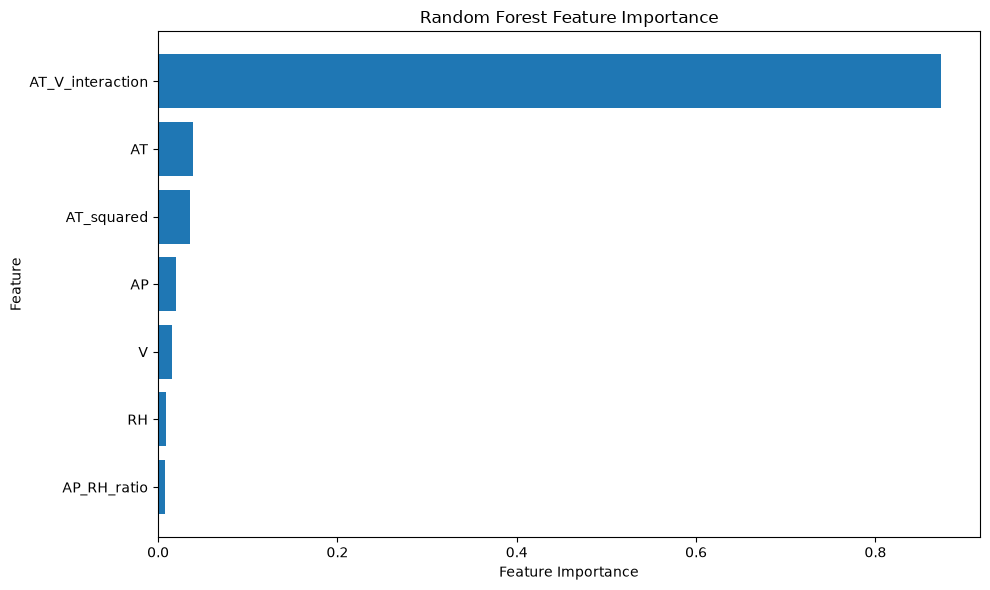

In [56]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [57]:
feature_importance.to_csv(
    "../models/ml1_feature_importance.csv",
    index=False
)

print("Feature importance berhasil disimpan.")

Feature importance berhasil disimpan.


## Kesimpulan Feature Engineering + Validation

Pada tahap ini dilakukan evaluasi feature engineering dengan membandingkan Random Forest menggunakan baseline feature set dan engineered feature set.

### Hasil Test Set

| Feature Set | MAE | RMSE | R² |
|---|---:|---:|---:|
| Baseline | 2.405946 | 3.431440 | 0.959935 |
| Engineered | 2.450048 | 3.477157 | 0.958861 |

Pada test set, engineered feature set menghasilkan MAE dan RMSE yang lebih tinggi serta R² yang sedikit lebih rendah dibandingkan baseline feature set.

### Hasil 5-Fold Cross-Validation

| Feature Set | Mean MAE | Mean RMSE | Mean R² |
|---|---:|---:|---:|
| Baseline | 2.444547 | 3.405214 | 0.959844 |
| Engineered | 2.513219 | 3.481429 | 0.958055 |

Hasil 5-Fold Cross-Validation menunjukkan pola yang sama. Engineered feature set belum memberikan peningkatan performa dibandingkan baseline feature set.

### Feature Importance

Pada Random Forest dengan engineered feature set, `AT_V_interaction` memiliki nilai feature importance sebesar `0.872991`, sedangkan fitur lainnya memiliki nilai importance yang lebih rendah.

Feature importance digunakan sebagai analisis pendukung untuk memahami penggunaan fitur oleh model dan tidak digunakan sebagai satu-satunya dasar dalam menentukan feature set.

### Kesimpulan Feature Engineering

Feature engineering berhasil dilakukan dengan menghasilkan tiga fitur turunan, yaitu `AT_squared`, `AT_V_interaction`, dan `AP_RH_ratio`. Namun, hasil evaluasi pada test set dan 5-Fold Cross-Validation menunjukkan bahwa penambahan fitur tersebut belum meningkatkan performa Random Forest. Oleh karena itu, feature set baseline (`AT`, `V`, `AP`, dan `RH`) digunakan untuk tahap pembangunan model final.

Engineered features tetap didokumentasikan sebagai hasil eksperimen feature engineering 

In [58]:
import os

artifact_files = [
    "../models/ml1_feature_engineering_comparison.csv",
    "../models/ml1_cross_validation_comparison.csv",
    "../models/ml1_feature_importance.csv"
]

for file in artifact_files:
    status = "OK" if os.path.exists(file) else "TIDAK ADA"
    print(f"{file}: {status}")

../models/ml1_feature_engineering_comparison.csv: OK
../models/ml1_cross_validation_comparison.csv: OK
../models/ml1_feature_importance.csv: OK
